In [1]:
import uproot

file_path = "CERN1.root"

f = uproot.open(file_path)
print(f.keys())

tree = f["Events"]
print(tree.keys()[:50])

branches = tree.keys()

tau_branches = [b for b in branches if b.startswith("Tau_")]
tau_branches[:30]

['tag;1', 'Events;1', 'LuminosityBlocks;1', 'Runs;1', 'MetaData;1', 'ParameterSets;1']
['run', 'luminosityBlock', 'event', 'nboostedTau', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'boostedTau_neutralIso', 'boostedTau_phi', 'boostedTau_photonsOutsideSignalCone', 'boostedTau_pt', 'boostedTau_puCorr', 'boostedTau_rawAntiEle2018', 'boostedTau_rawIso', 'boostedTau_rawIsodR03', 'boostedTau_rawMVAnewDM2017v2', 'boostedTau_rawMVAoldDM2017v2', 'boostedTau_rawMVAoldDMdR032017v2', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_idMVAoldDMdR032017v2', 'CaloMET_phi', 'CaloMET_pt', 'CaloMET_sumEt', 'ChsMET_phi', 'ChsMET_pt', 'ChsMET_sumEt', 'nCorrT1METJet', 'CorrT1METJet_area', 'CorrT1METJet_eta', 'CorrT1METJet_muonSubt

['Tau_chargedIso',
 'Tau_dxy',
 'Tau_dz',
 'Tau_eta',
 'Tau_leadTkDeltaEta',
 'Tau_leadTkDeltaPhi',
 'Tau_leadTkPtOverTauPt',
 'Tau_mass',
 'Tau_neutralIso',
 'Tau_phi',
 'Tau_photonsOutsideSignalCone',
 'Tau_pt',
 'Tau_puCorr',
 'Tau_rawDeepTau2017v2p1VSe',
 'Tau_rawDeepTau2017v2p1VSjet',
 'Tau_rawDeepTau2017v2p1VSmu',
 'Tau_rawIso',
 'Tau_rawIsodR03',
 'Tau_charge',
 'Tau_decayMode',
 'Tau_jetIdx',
 'Tau_idAntiEleDeadECal',
 'Tau_idAntiMu',
 'Tau_idDecayModeOldDMs',
 'Tau_idDeepTau2017v2p1VSe',
 'Tau_idDeepTau2017v2p1VSjet',
 'Tau_idDeepTau2017v2p1VSmu',
 'Tau_cleanmask']

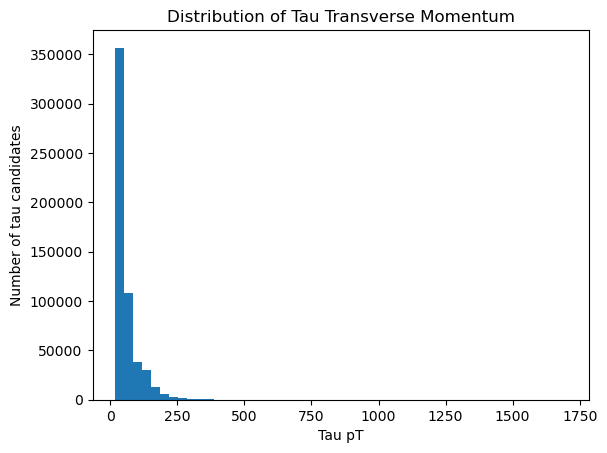

In [2]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt

tree = f["Events"]

tau_pt = tree["Tau_pt"].array(library="ak")

# Flatten because each event can have 0, 1, or many tau candidates
tau_pt_flat = ak.flatten(tau_pt)

plt.hist(tau_pt_flat, bins=50)
plt.xlabel("Tau pT")
plt.ylabel("Number of tau candidates")
plt.title("Distribution of Tau Transverse Momentum")
plt.show()

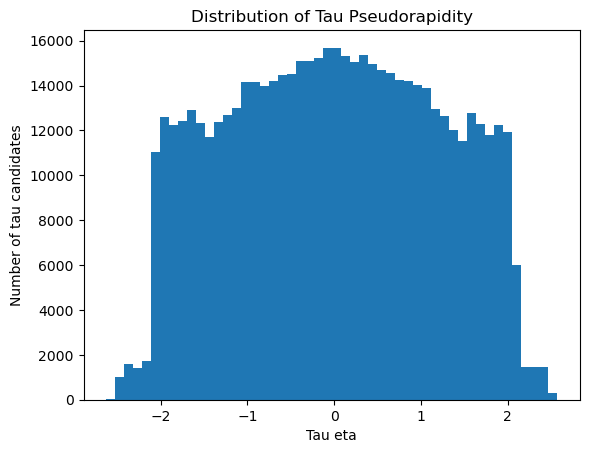

In [3]:
tau_eta = tree["Tau_eta"].array(library="ak")
tau_eta_flat = ak.flatten(tau_eta)

plt.hist(tau_eta_flat, bins=50)
plt.xlabel("Tau eta")
plt.ylabel("Number of tau candidates")
plt.title("Distribution of Tau Pseudorapidity")
plt.show()

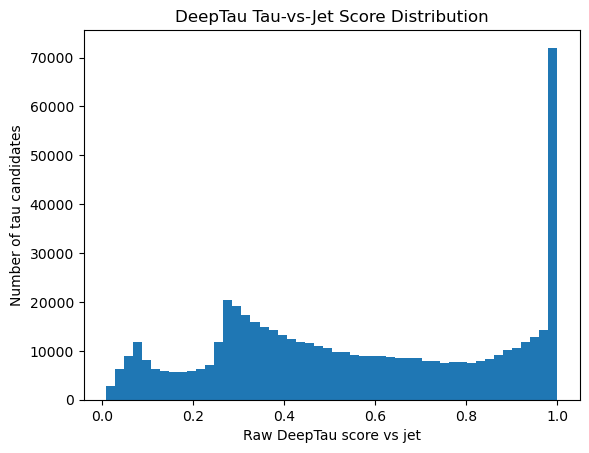

In [4]:
tau_vs_jet = tree["Tau_rawDeepTau2017v2p1VSjet"].array(library="ak")
tau_vs_jet_flat = ak.flatten(tau_vs_jet)

plt.hist(tau_vs_jet_flat, bins=50)
plt.xlabel("Raw DeepTau score vs jet")
plt.ylabel("Number of tau candidates")
plt.title("DeepTau Tau-vs-Jet Score Distribution")
plt.show()

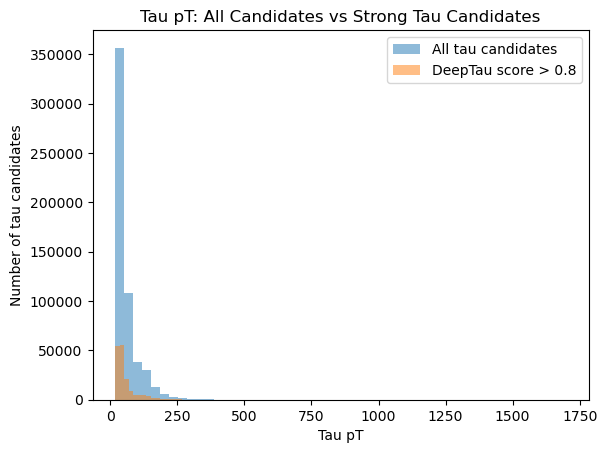

In [5]:
tau_pt = tree["Tau_pt"].array(library="ak")
tau_eta = tree["Tau_eta"].array(library="ak")
tau_vs_jet = tree["Tau_rawDeepTau2017v2p1VSjet"].array(library="ak")

pt_flat = ak.flatten(tau_pt)
eta_flat = ak.flatten(tau_eta)
score_flat = ak.flatten(tau_vs_jet)

strong_tau_mask = score_flat > 0.8

plt.hist(pt_flat, bins=50, alpha=0.5, label="All tau candidates")
plt.hist(pt_flat[strong_tau_mask], bins=50, alpha=0.5, label="DeepTau score > 0.8")
plt.xlabel("Tau pT")
plt.ylabel("Number of tau candidates")
plt.title("Tau pT: All Candidates vs Strong Tau Candidates")
plt.legend()
plt.show()

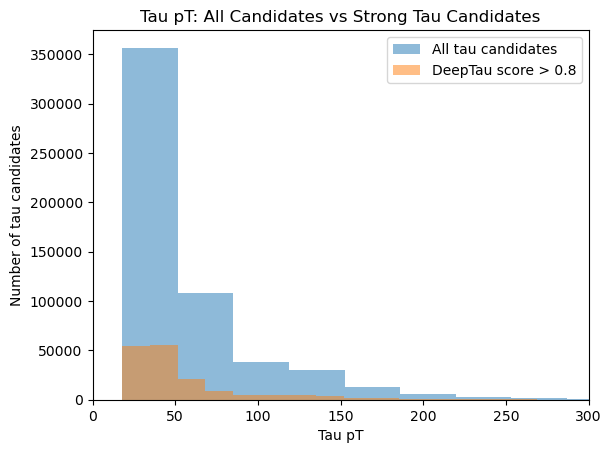

In [6]:
plt.hist(pt_flat, bins=50, alpha=0.5, label="All tau candidates")
plt.hist(pt_flat[strong_tau_mask], bins=50, alpha=0.5, label="DeepTau score > 0.8")

plt.xlim(0, 300)

plt.xlabel("Tau pT")
plt.ylabel("Number of tau candidates")
plt.title("Tau pT: All Candidates vs Strong Tau Candidates")
plt.legend()
plt.show()

In [7]:
total_candidates = len(pt_flat)
strong_candidates = len(pt_flat[strong_tau_mask])

survival_rate = strong_candidates / total_candidates

print("Total tau candidates:", total_candidates)
print("Strong tau candidates:", strong_candidates)
print("Survival rate:", survival_rate)

Total tau candidates: 558396
Strong tau candidates: 165099
Survival rate: 0.29566651623578966


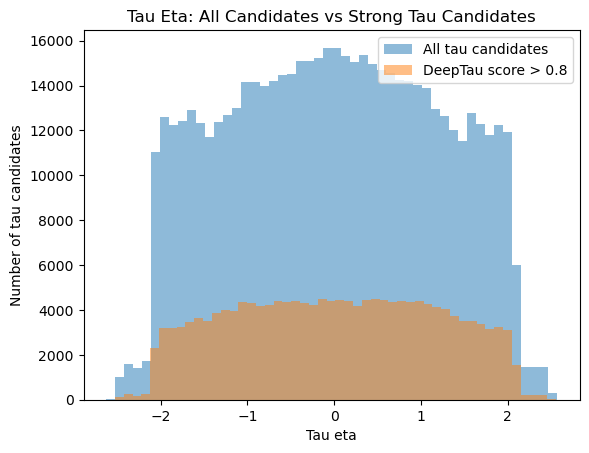

In [8]:
plt.hist(eta_flat, bins=50, alpha=0.5, label="All tau candidates")
plt.hist(eta_flat[strong_tau_mask], bins=50, alpha=0.5, label="DeepTau score > 0.8")

plt.xlabel("Tau eta")
plt.ylabel("Number of tau candidates")
plt.title("Tau Eta: All Candidates vs Strong Tau Candidates")
plt.legend()
plt.show()

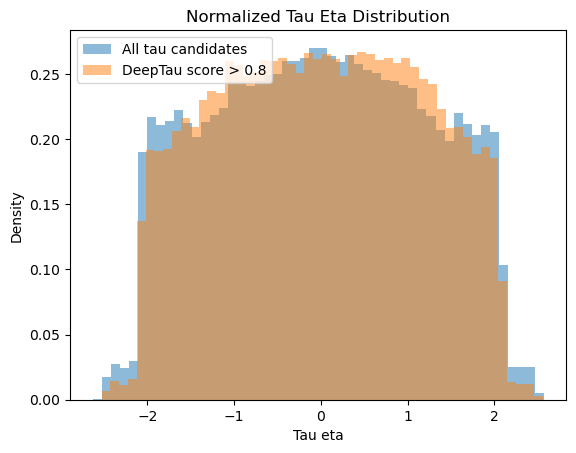

In [9]:
plt.hist(eta_flat, bins=50, alpha=0.5, density=True, label="All tau candidates")
plt.hist(eta_flat[strong_tau_mask], bins=50, alpha=0.5, density=True, label="DeepTau score > 0.8")

plt.xlabel("Tau eta")
plt.ylabel("Density")
plt.title("Normalized Tau Eta Distribution")
plt.legend()
plt.show()